# Baseline 3 — QASPER Hybrid Retrieval

This notebook combines the established Baseline 1 (BM25) and Baseline 2 (BGE + FAISS HNSW) configurations.

QASPER paths used ONLY:
- /kaggle/input/datasets/arvindnandigam/data-qasper/data/qasper/answers
- /kaggle/input/datasets/arvindnandigam/data-qasper/data/qasper/corpus
- /kaggle/input/datasets/arvindnandigam/data-qasper/data/qasper/qrels
- /kaggle/input/datasets/arvindnandigam/data-qasper/data/qasper/queries

No meetings.csv. No new chunking. The supplied QASPER corpus is used as-is.

Weighted fusion sweeps only alpha = 0.0 ... 1.0 in steps of 0.1.
RRF is also evaluated with fixed RRF constant 60.

Metrics:
Precision@K, Recall@K, F1@K, Hit@K, nDCG@K, MRR, MAP,
mean/P50/P95/P99 latency, candidate overlap, oracle union recall,
and complementary BM25/dense evidence diagnostics.


In [1]:
!pip install -q rank-bm25 sentence-transformers faiss-cpu


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 90.4 MB/s eta 0:00:00


In [2]:
import re, json, math, time
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer
import faiss

BASE = Path("/kaggle/input/datasets/arvindnandigam/data-qasper/data/qasper")
ANSWERS_DIR = BASE / "answers"
CORPUS_DIR = BASE / "corpus"
QRELS_DIR = BASE / "qrels"
QUERIES_DIR = BASE / "queries"

OUT = Path("/kaggle/working/baseline3_qasper_hybrid")
OUT.mkdir(parents=True, exist_ok=True)

RESULTS_CSV = OUT / "baseline3_hybrid_results.csv"
PER_QUERY_CSV = OUT / "baseline3_hybrid_per_query.csv"
CONFIG_JSON = OUT / "baseline3_config.json"

DENSE_MODEL = "BAAI/bge-base-en-v1.5"
HNSW_M = 16
HNSW_EF_CONSTRUCTION = 200
HNSW_EF_SEARCH = 256
CANDIDATE_K = 50
K_VALUES = [1, 3, 5, 10, 20, 50]
ALPHAS = [round(float(x), 1) for x in np.linspace(0, 1, 11)]
RRF_K = 60

print("FAISS:", faiss.__version__)
print("BASE:", BASE)
print("Alphas:", ALPHAS)


FAISS: 1.15.0
BASE: /kaggle/input/datasets/arvindnandigam/data-qasper/data/qasper
Alphas: [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]


In [3]:
def load_dir(directory):
    frames = []
    for f in sorted(directory.glob("*")):
        if f.suffix.lower() == ".parquet":
            frames.append(pd.read_parquet(f))
        elif f.suffix.lower() == ".csv":
            frames.append(pd.read_csv(f))
        elif f.suffix.lower() == ".jsonl":
            frames.append(pd.read_json(f, lines=True))
        elif f.suffix.lower() == ".json":
            with open(f, encoding="utf-8") as fh:
                obj = json.load(fh)
            frames.append(pd.DataFrame(obj if isinstance(obj, list) else [obj]))
    if not frames:
        raise FileNotFoundError(directory)
    return pd.concat(frames, ignore_index=True)

corpus = load_dir(CORPUS_DIR)
queries = load_dir(QUERIES_DIR)
qrels_df = load_dir(QRELS_DIR)

corpus["id"] = corpus["id"].astype(str)
corpus["text"] = corpus["text"].fillna("").astype(str)
queries["id"] = queries["id"].astype(str)
queries["text"] = queries["text"].fillna("").astype(str)
qrels_df["query_id"] = qrels_df["query_id"].astype(str)
qrels_df["corpus_id"] = qrels_df["corpus_id"].astype(str)
qrels_df["score"] = qrels_df["score"].astype(float)

assert len(corpus) == 81550
assert len(queries) == 1310
assert len(qrels_df) == 3434

doc_ids = corpus["id"].tolist()
query_text = dict(zip(queries["id"], queries["text"]))

qrels = defaultdict(set)
for _, r in qrels_df.iterrows():
    if r["score"] > 0:
        qrels[r["query_id"]].add(r["corpus_id"])
qrels = dict(qrels)

eval_qids = [qid for qid in queries["id"] if qid in qrels and qrels[qid]]

assert len(eval_qids) == 1310
assert not (set(qrels_df["corpus_id"]) - set(doc_ids))
assert not (set(qrels_df["query_id"]) - set(query_text))

print("Corpus:", len(corpus))
print("Test queries:", len(eval_qids))
print("Qrels:", len(qrels_df))
print("Gold chunks/question:",
      min(map(len, qrels.values())),
      max(map(len, qrels.values())),
      np.mean([len(qrels[q]) for q in eval_qids]))


Corpus: 81550
Test queries: 1310
Qrels: 3434
Gold chunks/question: 1 67 2.621374045801527


In [4]:
# Baseline 1: BM25

def tokenize(text):
    return re.findall(r"(?u)\b\w+\b", text.lower())

t0 = time.perf_counter()
tokenized = [tokenize(x) for x in tqdm(corpus["text"], desc="Tokenizing")]
print("Tokenization seconds:", time.perf_counter() - t0)

t0 = time.perf_counter()
bm25 = BM25Okapi(tokenized)
bm25_build_seconds = time.perf_counter() - t0
print("BM25 build seconds:", bm25_build_seconds)


Tokenizing:   0%|          | 0/81550 [00:00<?, ?it/s]

Tokenization seconds: 2.0902941120000094
BM25 build seconds: 1.6768998319999753


In [5]:
# Baseline 2: selected dense configuration

import torch
print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())
for i in range(torch.cuda.device_count()):
    print(i, torch.cuda.get_device_name(i))

encoder = SentenceTransformer(DENSE_MODEL)
print("Encoder device:", encoder.device)


CUDA available: True
GPU count: 2
0 Tesla T4
1 Tesla T4


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encoder device: cuda:0


In [6]:
t0 = time.perf_counter()

corpus_embeddings = encoder.encode(
    corpus["text"].tolist(),
    batch_size=128,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
).astype(np.float32)

embedding_seconds = time.perf_counter() - t0

assert len(corpus_embeddings) == len(corpus)

print("Embedding shape:", corpus_embeddings.shape)
print("Embedding seconds:", embedding_seconds)


Batches:   0%|          | 0/638 [00:00<?, ?it/s]

Embedding shape: (81550, 768)
Embedding seconds: 1010.046334423


In [7]:
dimension = corpus_embeddings.shape[1]

t0 = time.perf_counter()

hnsw = faiss.IndexHNSWFlat(
    dimension,
    HNSW_M,
    faiss.METRIC_INNER_PRODUCT
)
hnsw.hnsw.efConstruction = HNSW_EF_CONSTRUCTION
hnsw.hnsw.efSearch = HNSW_EF_SEARCH
hnsw.add(corpus_embeddings)

hnsw_build_seconds = time.perf_counter() - t0

assert hnsw.ntotal == len(corpus)

print("HNSW vectors:", hnsw.ntotal)
print("HNSW build seconds:", hnsw_build_seconds)


HNSW vectors: 81550
HNSW build seconds: 41.44921386500005


In [8]:
# CRITICAL: both retrievers return QASPER string IDs, never integer row indices.

def retrieve_bm25(query, k=CANDIDATE_K):
    t0 = time.perf_counter()
    scores = np.asarray(bm25.get_scores(tokenize(query)), dtype=np.float32)
    k_eff = min(k, len(scores))
    idx = np.argpartition(-scores, k_eff - 1)[:k_eff]
    idx = idx[np.argsort(-scores[idx])]
    latency = (time.perf_counter() - t0) * 1000

    return {doc_ids[int(i)]: float(scores[int(i)]) for i in idx}, latency


def retrieve_dense(query, k=CANDIDATE_K):
    t0 = time.perf_counter()
    qemb = encoder.encode(
        [query],
        convert_to_numpy=True,
        normalize_embeddings=True
    ).astype(np.float32)

    scores, indices = hnsw.search(qemb, min(k, len(doc_ids)))
    latency = (time.perf_counter() - t0) * 1000

    result = {}
    for rank, idx in enumerate(indices[0]):
        idx = int(idx)
        if idx >= 0:
            result[doc_ids[idx]] = float(scores[0, rank])
    return result, latency

print("ID-safe retrieval functions ready.")


ID-safe retrieval functions ready.


In [9]:
# Mandatory ID sanity check — run before caching

qid0 = eval_qids[0]
bm_test, _ = retrieve_bm25(query_text[qid0])
dense_test, _ = retrieve_dense(query_text[qid0])
gold_test = qrels[qid0]

print("Question:", qid0)
print("Gold:", list(gold_test)[:5])
print("BM25:", list(bm_test)[:5])
print("Dense:", list(dense_test)[:5])
print("BM25 type:", type(next(iter(bm_test))))
print("Dense type:", type(next(iter(dense_test))))
print("Gold type:", type(next(iter(gold_test))))

assert isinstance(next(iter(bm_test)), str)
assert isinstance(next(iter(dense_test)), str)
assert isinstance(next(iter(gold_test)), str)
assert set(bm_test).issubset(set(doc_ids))
assert set(dense_test).issubset(set(doc_ids))

print("ID MAPPING CHECK PASSED")


Question: 397a1e851aab41c455c2b284f5e4947500d797f0
Gold: ['1911.10742_00015']
BM25: ['1911.03562_00010', '1911.10742_00014', '1911.10742_00054', '1911.10742_00046', '1905.07562_00013']
Dense: ['1912.13337_00025', '1901.09501_00017', '1809.00530_00030', '1912.01046_00033', '1911.12848_00073']
BM25 type: <class 'str'>
Dense type: <class 'str'>
Gold type: <class 'str'>
ID MAPPING CHECK PASSED


In [10]:
# Build cache BEFORE ANY alpha/RRF evaluation.

cache = []
t0 = time.perf_counter()

for qid in tqdm(eval_qids, desc="Caching retrieval"):
    bm_scores, bm_latency = retrieve_bm25(query_text[qid], CANDIDATE_K)
    dense_scores, dense_latency = retrieve_dense(query_text[qid], CANDIDATE_K)

    cache.append({
        "qid": qid,
        "gold": qrels[qid],
        "bm_scores": bm_scores,
        "dense_scores": dense_scores,
        "bm_latency_ms": bm_latency,
        "dense_latency_ms": dense_latency
    })

cache_build_seconds = time.perf_counter() - t0

assert len(cache) == 1310

bm_hits = sum(bool(set(x["bm_scores"]) & x["gold"]) for x in cache)
dense_hits = sum(bool(set(x["dense_scores"]) & x["gold"]) for x in cache)

print("Cached:", len(cache))
print("BM25 questions with >=1 gold candidate:", bm_hits)
print("Dense questions with >=1 gold candidate:", dense_hits)

assert bm_hits > 0
assert dense_hits > 0


Caching retrieval:   0%|          | 0/1310 [00:00<?, ?it/s]

Cached: 1310
BM25 questions with >=1 gold candidate: 351
Dense questions with >=1 gold candidate: 374


In [11]:
def precision_at_k(ids, gold, k):
    return sum(x in gold for x in ids[:k]) / k

def recall_at_k(ids, gold, k):
    return sum(x in gold for x in ids[:k]) / len(gold) if gold else np.nan

def f1(p, r):
    return 0.0 if p + r == 0 else 2*p*r/(p+r)

def hit_at_k(ids, gold, k):
    return float(any(x in gold for x in ids[:k]))

def rr(ids, gold):
    for rank, x in enumerate(ids, 1):
        if x in gold:
            return 1.0 / rank
    return 0.0

def average_precision(ids, gold):
    if not gold:
        return np.nan
    hits = 0
    total = 0.0
    for rank, x in enumerate(ids, 1):
        if x in gold:
            hits += 1
            total += hits / rank
    return total / len(gold)

def ndcg_at_k(ids, gold, k):
    top = ids[:k]
    dcg = sum(
        (1.0 if x in gold else 0.0) / math.log2(rank + 1)
        for rank, x in enumerate(top, 1)
    )
    ideal = min(len(gold), k)
    if ideal == 0:
        return np.nan
    idcg = sum(1.0 / math.log2(rank + 1) for rank in range(1, ideal + 1))
    return dcg / idcg


In [12]:
def top_ids(scores, k):
    return [
        doc_id for doc_id, _ in sorted(
            scores.items(),
            key=lambda z: z[1],
            reverse=True
        )[:k]
    ]

def minmax(scores):
    if not scores:
        return {}
    keys = list(scores)
    values = np.asarray([scores[k] for k in keys], dtype=float)
    lo, hi = values.min(), values.max()
    if np.isclose(lo, hi):
        vals = np.zeros_like(values)
    else:
        vals = (values - lo) / (hi - lo)
    return dict(zip(keys, vals))

def weighted_fusion(bm_scores, dense_scores, alpha):
    # Exact endpoints: reproduce the original baselines exactly
    if alpha == 0.0:
        return top_ids(dense_scores, CANDIDATE_K)

    if alpha == 1.0:
        return top_ids(bm_scores, CANDIDATE_K)

    bm = minmax(bm_scores)
    dense = minmax(dense_scores)

    all_ids = set(bm) | set(dense)

    fused = {
        doc_id:
            alpha * bm.get(doc_id, 0.0)
            + (1.0 - alpha) * dense.get(doc_id, 0.0)
        for doc_id in all_ids
    }

    # Deterministic tie-breaking
    ranked = sorted(
        fused.items(),
        key=lambda x: (-x[1], x[0])
    )

    return [doc_id for doc_id, _ in ranked[:CANDIDATE_K]]

def rrf_fusion(bm_scores, dense_scores, rrf_k=RRF_K):
    fused = defaultdict(float)
    for rank, (x, _) in enumerate(sorted(bm_scores.items(), key=lambda z:z[1], reverse=True), 1):
        fused[x] += 1.0 / (rrf_k + rank)
    for rank, (x, _) in enumerate(sorted(dense_scores.items(), key=lambda z:z[1], reverse=True), 1):
        fused[x] += 1.0 / (rrf_k + rank)
    return [x for x, _ in sorted(fused.items(), key=lambda z:z[1], reverse=True)]

def jaccard(bm, dense, k):
    a, b = set(top_ids(bm, k)), set(top_ids(dense, k))
    u = a | b
    return len(a & b) / len(u) if u else 0.0

def union_recall(bm, dense, gold, k):
    a, b = set(top_ids(bm, k)), set(top_ids(dense, k))
    return len((a | b) & gold) / len(gold) if gold else np.nan

def overlap_count(bm, dense, k):
    return len(set(top_ids(bm, k)) & set(top_ids(dense, k)))

def evidence_breakdown(bm, dense, gold, k):
    a, b = set(top_ids(bm, k)), set(top_ids(dense, k))
    ag, bg = a & gold, b & gold
    return {
        "bm25_gold_hits": len(ag),
        "dense_gold_hits": len(bg),
        "both_gold_hits": len(ag & bg),
        "bm25_only_gold_hits": len(ag - bg),
        "dense_only_gold_hits": len(bg - ag)
    }


In [13]:
# Weighted hybrid alpha sweep

per_query = []

for alpha in ALPHAS:
    for row in tqdm(cache, desc=f"alpha={alpha:.1f}", leave=False):
        ranked = weighted_fusion(row["bm_scores"], row["dense_scores"], alpha)
        latency = row["bm_latency_ms"] + row["dense_latency_ms"]

        for k in K_VALUES:
            p = precision_at_k(ranked, row["gold"], k)
            r = recall_at_k(ranked, row["gold"], k)
            d = evidence_breakdown(row["bm_scores"], row["dense_scores"], row["gold"], k)

            per_query.append({
                "method": "weighted_fusion",
                "alpha": alpha,
                "k": k,
                "qid": row["qid"],
                "precision": p,
                "recall": r,
                "f1": f1(p, r),
                "hit_rate": hit_at_k(ranked, row["gold"], k),
                "ndcg": ndcg_at_k(ranked, row["gold"], k),
                "mrr": rr(ranked, row["gold"]),
                "ap": average_precision(ranked, row["gold"]),
                "latency_total_ms": latency,
                "candidate_jaccard": jaccard(row["bm_scores"], row["dense_scores"], k),
                "oracle_union_recall": union_recall(row["bm_scores"], row["dense_scores"], row["gold"], k),
                "bm25_dense_overlap": overlap_count(row["bm_scores"], row["dense_scores"], k),
                **d
            })

print("Weighted rows:", len([x for x in per_query if x["method"] == "weighted_fusion"]))


alpha=0.0:   0%|          | 0/1310 [00:00<?, ?it/s]

alpha=0.1:   0%|          | 0/1310 [00:00<?, ?it/s]

alpha=0.2:   0%|          | 0/1310 [00:00<?, ?it/s]

alpha=0.3:   0%|          | 0/1310 [00:00<?, ?it/s]

alpha=0.4:   0%|          | 0/1310 [00:00<?, ?it/s]

...

alpha=0.7:   0%|          | 0/1310 [00:00<?, ?it/s]

alpha=0.8:   0%|          | 0/1310 [00:00<?, ?it/s]

alpha=0.9:   0%|          | 0/1310 [00:00<?, ?it/s]

alpha=1.0:   0%|          | 0/1310 [00:00<?, ?it/s]

Weighted rows: 86460


In [14]:
# Add the two underlying baselines

for row in tqdm(cache, desc="Baseline metrics"):
    for method, scores, latency in [
        ("BM25", row["bm_scores"], row["bm_latency_ms"]),
        ("Dense_BGE_HNSW", row["dense_scores"], row["dense_latency_ms"])
    ]:
        ranked = top_ids(scores, CANDIDATE_K)

        for k in K_VALUES:
            p = precision_at_k(ranked, row["gold"], k)
            r = recall_at_k(ranked, row["gold"], k)

            per_query.append({
                "method": method,
                "alpha": np.nan,
                "k": k,
                "qid": row["qid"],
                "precision": p,
                "recall": r,
                "f1": f1(p, r),
                "hit_rate": hit_at_k(ranked, row["gold"], k),
                "ndcg": ndcg_at_k(ranked, row["gold"], k),
                "mrr": rr(ranked, row["gold"]),
                "ap": average_precision(ranked, row["gold"]),
                "latency_total_ms": latency,
                "candidate_jaccard": np.nan,
                "oracle_union_recall": np.nan,
                "bm25_dense_overlap": np.nan,
                "bm25_gold_hits": np.nan,
                "dense_gold_hits": np.nan,
                "both_gold_hits": np.nan,
                "bm25_only_gold_hits": np.nan,
                "dense_only_gold_hits": np.nan
            })


Baseline metrics:   0%|          | 0/1310 [00:00<?, ?it/s]

In [15]:
# RRF

for row in tqdm(cache, desc="RRF"):
    ranked = rrf_fusion(row["bm_scores"], row["dense_scores"], RRF_K)
    latency = row["bm_latency_ms"] + row["dense_latency_ms"]

    for k in K_VALUES:
        p = precision_at_k(ranked, row["gold"], k)
        r = recall_at_k(ranked, row["gold"], k)
        d = evidence_breakdown(row["bm_scores"], row["dense_scores"], row["gold"], k)

        per_query.append({
            "method": "RRF",
            "alpha": np.nan,
            "k": k,
            "qid": row["qid"],
            "precision": p,
            "recall": r,
            "f1": f1(p, r),
            "hit_rate": hit_at_k(ranked, row["gold"], k),
            "ndcg": ndcg_at_k(ranked, row["gold"], k),
            "mrr": rr(ranked, row["gold"]),
            "ap": average_precision(ranked, row["gold"]),
            "latency_total_ms": latency,
            "candidate_jaccard": jaccard(row["bm_scores"], row["dense_scores"], k),
            "oracle_union_recall": union_recall(row["bm_scores"], row["dense_scores"], row["gold"], k),
            "bm25_dense_overlap": overlap_count(row["bm_scores"], row["dense_scores"], k),
            **d
        })


RRF:   0%|          | 0/1310 [00:00<?, ?it/s]

In [16]:
# Aggregate

per_query_df = pd.DataFrame(per_query)

summary_df = (
    per_query_df
    .groupby(["method", "alpha", "k"], dropna=False, as_index=False)
    .agg(
        num_queries=("qid", "nunique"),
        precision=("precision", "mean"),
        recall=("recall", "mean"),
        f1=("f1", "mean"),
        hit_rate=("hit_rate", "mean"),
        ndcg=("ndcg", "mean"),
        mrr=("mrr", "mean"),
        map=("ap", "mean"),
        mean_latency_ms=("latency_total_ms", "mean"),
        median_latency_ms=("latency_total_ms", "median"),
        p95_latency_ms=("latency_total_ms", lambda x: np.percentile(x, 95)),
        p99_latency_ms=("latency_total_ms", lambda x: np.percentile(x, 99)),
        candidate_jaccard=("candidate_jaccard", "mean"),
        oracle_union_recall=("oracle_union_recall", "mean"),
        bm25_dense_overlap=("bm25_dense_overlap", "mean"),
        bm25_gold_hits=("bm25_gold_hits", "mean"),
        dense_gold_hits=("dense_gold_hits", "mean"),
        both_gold_hits=("both_gold_hits", "mean"),
        bm25_only_gold_hits=("bm25_only_gold_hits", "mean"),
        dense_only_gold_hits=("dense_only_gold_hits", "mean")
    )
)

display(summary_df)


,method,alpha,k,num_queries,precision,recall,f1,hit_rate,ndcg,mrr,...,p95_latency_ms,p99_latency_ms,candidate_jaccard,oracle_union_recall,bm25_dense_overlap,bm25_gold_hits,dense_gold_hits,both_gold_hits,bm25_only_gold_hits,dense_only_gold_hits
0,BM25,NaN,1,1310,0.048092,0.027829,0.032460,0.048092,0.048092,0.084936,...,364.198179,494.036777,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BM25,NaN,3,1310,0.037405,0.062709,0.043082,0.097710,0.058322,0.084936,...,364.198179,494.036777,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,BM25,NaN,5,1310,0.028244,0.075095,0.037893,0.117557,0.062695,0.084936,...,364.198179,494.036777,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,BM25,NaN,10,1310,0.019542,0.101304,0.030512,0.154962,0.071860,0.084936,...,364.198179,494.036777,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,BM25,NaN,20,1310,0.013397,0.136957,0.023265,0.204580,0.082623,0.084936,...,364.198179,494.036777,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,weighted_fusion,1.0,3,1310,0.037405,0.062709,0.043082,0.097710,0.058322,0.084936,...,377.405385,508.484182,0.052290,0.110783,0.243511,0.112214,0.132061,0.046565,0.065649,0.085496
80,weighted_fusion,1.0,5,1310,0.028244,0.075095,0.037893,0.117557,0.062695,0.084936,...,377.405385,508.484182,0.053235,0.129254,0.428244,0.141221,0.164885,0.066412,0.074809,0.098473
81,weighted_fusion,1.0,10,1310,0.019542,0.101304,0.030512,0.154962,0.071860,0.084936,...,377.405385,508.484182,0.055389,0.158560,0.935878,0.195420,0.206870,0.099237,0.096183,0.107634
82,weighted_fusion,1.0,20,1310,0.013397,0.136957,0.023265,0.204580,0.082623,0.084936,...,377.405385,508.484182,0.057811,0.208081,2.013740,0.267939,0.281679,0.145038,0.122901,0.136641


In [17]:
# Select alpha using MAP at K=10

alpha_table = summary_df[
    (summary_df["method"] == "weighted_fusion") &
    (summary_df["k"] == 10)
].sort_values(["map", "ndcg", "recall"], ascending=False)

BEST_ALPHA = float(alpha_table.iloc[0]["alpha"])

print("Best alpha:", BEST_ALPHA)
display(alpha_table)


Best alpha: 0.5


,method,alpha,k,num_queries,precision,recall,f1,hit_rate,ndcg,mrr,...,p95_latency_ms,p99_latency_ms,candidate_jaccard,oracle_union_recall,bm25_dense_overlap,bm25_gold_hits,dense_gold_hits,both_gold_hits,bm25_only_gold_hits,dense_only_gold_hits
51,weighted_fusion,0.5,10,1310,0.025267,0.136798,0.039880,0.206870,0.096673,0.112147,...,377.405385,508.484182,0.055389,0.15856,0.935878,0.19542,0.20687,0.099237,0.096183,0.107634
45,weighted_fusion,0.4,10,1310,0.025115,0.137942,0.039770,0.208397,0.096408,0.111164,...,377.405385,508.484182,0.055389,0.15856,0.935878,0.19542,0.20687,0.099237,0.096183,0.107634
39,weighted_fusion,0.3,10,1310,0.023969,0.131153,0.037903,0.199237,0.093976,0.111136,...,377.405385,508.484182,0.055389,0.15856,0.935878,0.19542,0.20687,0.099237,0.096183,0.107634
57,weighted_fusion,0.6,10,1310,0.025344,0.136573,0.039872,0.205344,0.094429,0.108518,...,377.405385,508.484182,0.055389,0.15856,0.935878,0.19542,0.20687,0.099237,0.096183,0.107634
33,weighted_fusion,0.2,10,1310,0.022366,0.122680,0.035289,0.190076,0.088825,0.106241,...,377.405385,508.484182,0.055389,0.15856,0.935878,0.19542,0.20687,0.099237,0.096183,0.107634
63,weighted_fusion,0.7,10,1310,0.023893,0.127941,0.037545,0.191603,0.089298,0.105473,...,377.405385,508.484182,0.055389,0.15856,0.935878,0.19542,0.20687,0.099237,0.096183,0.107634
27,weighted_fusion,0.1,10,1310,0.021450,0.117328,0.033855,0.183969,0.084997,0.102253,...,377.405385,508.484182,0.055389,0.15856,0.935878,0.19542,0.20687,0.099237,0.096183,0.107634
69,weighted_fusion,0.8,10,1310,0.022290,0.116086,0.034822,0.173282,0.082123,0.097345,...,377.405385,508.484182,0.055389,0.15856,0.935878,0.19542,0.20687,0.099237,0.096183,0.107634
21,weighted_fusion,0.0,10,1310,0.020687,0.113232,0.032604,0.178626,0.082353,0.099833,...,377.405385,508.484182,0.055389,0.15856,0.935878,0.19542,0.20687,0.099237,0.096183,0.107634
75,weighted_fusion,0.9,10,1310,0.020611,0.106634,0.032180,0.161069,0.075413,0.089662,...,377.405385,508.484182,0.055389,0.15856,0.935878,0.19542,0.20687,0.099237,0.096183,0.107634


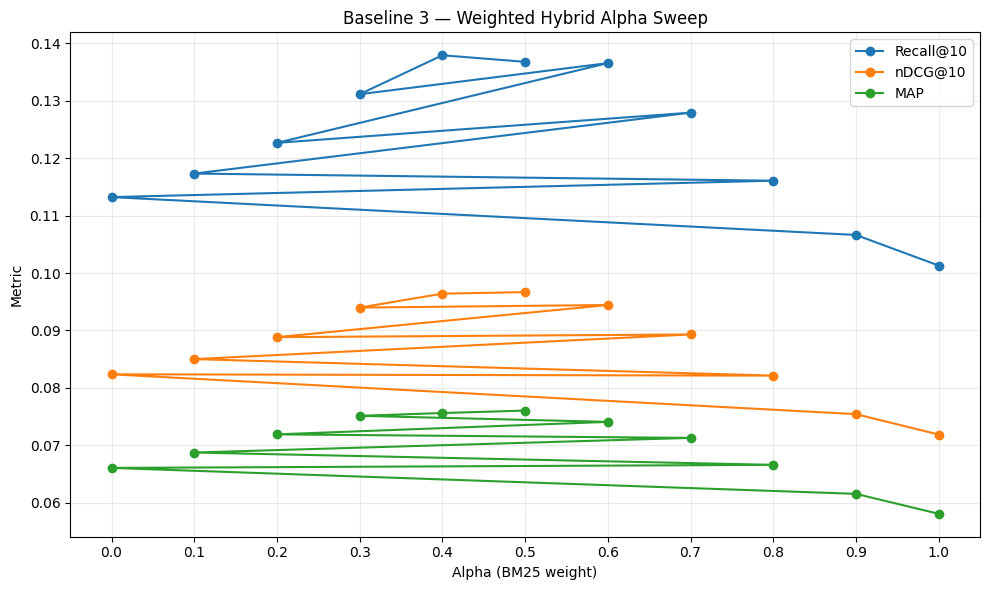

In [18]:
# Alpha sweep visualization

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(alpha_table["alpha"], alpha_table["recall"], marker="o", label="Recall@10")
plt.plot(alpha_table["alpha"], alpha_table["ndcg"], marker="o", label="nDCG@10")
plt.plot(alpha_table["alpha"], alpha_table["map"], marker="o", label="MAP")
plt.xlabel("Alpha (BM25 weight)")
plt.ylabel("Metric")
plt.title("Baseline 3 — Weighted Hybrid Alpha Sweep")
plt.xticks(ALPHAS)
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig(OUT / "baseline3_alpha_sweep.png", dpi=200, bbox_inches="tight")
plt.show()


In [19]:
# Save the single clean aggregate CSV

columns = [
    "method", "alpha", "k", "num_queries",
    "precision", "recall", "f1", "hit_rate", "ndcg", "mrr", "map",
    "mean_latency_ms", "median_latency_ms", "p95_latency_ms", "p99_latency_ms",
    "candidate_jaccard", "oracle_union_recall", "bm25_dense_overlap",
    "bm25_gold_hits", "dense_gold_hits", "both_gold_hits",
    "bm25_only_gold_hits", "dense_only_gold_hits"
]

clean_df = summary_df[columns].copy()
num_cols = clean_df.select_dtypes(include=[np.number]).columns
clean_df[num_cols] = clean_df[num_cols].round(6)

clean_df.to_csv(RESULTS_CSV, index=False)
per_query_df.to_csv(PER_QUERY_CSV, index=False)

config = {
    "experiment": "Baseline 3 - QASPER Hybrid Retrieval",
    "dataset_base": str(BASE),
    "corpus_size": len(corpus),
    "test_queries": len(eval_qids),
    "qrels": len(qrels_df),
    "dense_model": DENSE_MODEL,
    "hnsw_M": HNSW_M,
    "hnsw_efConstruction": HNSW_EF_CONSTRUCTION,
    "hnsw_efSearch": HNSW_EF_SEARCH,
    "candidate_k": CANDIDATE_K,
    "k_values": K_VALUES,
    "alphas": ALPHAS,
    "best_alpha": BEST_ALPHA,
    "rrf_k": RRF_K,
    "alpha_selection": "MAP@10"
}

with open(CONFIG_JSON, "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2)

print("Saved:", RESULTS_CSV)
print("Saved:", PER_QUERY_CSV)
print("Saved:", CONFIG_JSON)


Saved: /kaggle/working/baseline3_qasper_hybrid/baseline3_hybrid_results.csv
Saved: /kaggle/working/baseline3_qasper_hybrid/baseline3_hybrid_per_query.csv
Saved: /kaggle/working/baseline3_qasper_hybrid/baseline3_config.json


In [20]:
# Final validation

assert sorted(
    summary_df[summary_df["method"] == "weighted_fusion"]["alpha"].dropna().unique()
) == ALPHAS

assert sorted(summary_df["k"].unique()) == K_VALUES

for method in ["BM25", "Dense_BGE_HNSW", "RRF", "weighted_fusion"]:
    assert method in set(summary_df["method"])

assert clean_df["recall"].fillna(0).sum() > 0
assert RESULTS_CSV.exists()

print("=" * 72)
print("BASELINE 3 COMPLETE — VALIDATION PASSED")
print("=" * 72)
print("Best alpha:", BEST_ALPHA)
print("Result CSV:", RESULTS_CSV)
print("Per-query CSV:", PER_QUERY_CSV)
print("Config:", CONFIG_JSON)

display(
    clean_df[
        (clean_df["k"] == 10)
    ].sort_values(["method", "alpha"])
)


BASELINE 3 COMPLETE — VALIDATION PASSED
Best alpha: 0.5
Result CSV: /kaggle/working/baseline3_qasper_hybrid/baseline3_hybrid_results.csv
Per-query CSV: /kaggle/working/baseline3_qasper_hybrid/baseline3_hybrid_per_query.csv
Config: /kaggle/working/baseline3_qasper_hybrid/baseline3_config.json


,method,alpha,k,num_queries,precision,recall,f1,hit_rate,ndcg,mrr,...,p95_latency_ms,p99_latency_ms,candidate_jaccard,oracle_union_recall,bm25_dense_overlap,bm25_gold_hits,dense_gold_hits,both_gold_hits,bm25_only_gold_hits,dense_only_gold_hits
3,BM25,NaN,10,1310,0.019542,0.101304,0.030512,0.154962,0.071860,0.084936,...,364.198179,494.036777,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Dense_BGE_HNSW,NaN,10,1310,0.020687,0.113232,0.032604,0.178626,0.082353,0.099833,...,14.260061,16.344429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15,RRF,NaN,10,1310,0.025802,0.140048,0.040781,0.212977,0.096278,0.111760,...,377.405385,508.484182,0.055389,0.15856,0.935878,0.19542,0.20687,0.099237,0.096183,0.107634
21,weighted_fusion,0.0,10,1310,0.020687,0.113232,0.032604,0.178626,0.082353,0.099833,...,377.405385,508.484182,0.055389,0.15856,0.935878,0.19542,0.20687,0.099237,0.096183,0.107634
27,weighted_fusion,0.1,10,1310,0.021450,0.117328,0.033855,0.183969,0.084997,0.102253,...,377.405385,508.484182,0.055389,0.15856,0.935878,0.19542,0.20687,0.099237,0.096183,0.107634
33,weighted_fusion,0.2,10,1310,0.022366,0.122680,0.035289,0.190076,0.088825,0.106241,...,377.405385,508.484182,0.055389,0.15856,0.935878,0.19542,0.20687,0.099237,0.096183,0.107634
39,weighted_fusion,0.3,10,1310,0.023969,0.131153,0.037903,0.199237,0.093976,0.111136,...,377.405385,508.484182,0.055389,0.15856,0.935878,0.19542,0.20687,0.099237,0.096183,0.107634
45,weighted_fusion,0.4,10,1310,0.025115,0.137942,0.039770,0.208397,0.096408,0.111164,...,377.405385,508.484182,0.055389,0.15856,0.935878,0.19542,0.20687,0.099237,0.096183,0.107634
51,weighted_fusion,0.5,10,1310,0.025267,0.136798,0.039880,0.206870,0.096673,0.112147,...,377.405385,508.484182,0.055389,0.15856,0.935878,0.19542,0.20687,0.099237,0.096183,0.107634
57,weighted_fusion,0.6,10,1310,0.025344,0.136573,0.039872,0.205344,0.094429,0.108518,...,377.405385,508.484182,0.055389,0.15856,0.935878,0.19542,0.20687,0.099237,0.096183,0.107634
